Case Study: Quantum-Assisted Physics-Informed Neural Networks for Thermal and Flow Modeling in Electric Vehicle Battery Cooling Systems
 – Heat Distribution in a Battery cooling plate

We will use the Heat Equation to predict temperature inside a  Battery cooling plate  during manufacturing.**bold text**

In [ ]:
# If running in Google Colab for the first time
!pip install torch matplotlib numpy psutil

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import psutil

Quantum-Assisted Physics-Informed Neural Networks for Thermal and Flow Modeling in Electric Vehicle Battery Cooling Systems Case Study

Objective:

Predict the temperature distribution inside a Battery cooling plate  during manufacturing using a Physics-Informed Neural Network (PINN).

Physics:

Heat Equation

∂u/∂t = α ∂²u/∂x²

where

u(x,t) = temperature

x = position

t = time

α = thermal diffusivity

In [ ]:
alpha = 1.0

print("Thermal Diffusivity =", alpha)

Thermal Diffusivity = 1.0


In [ ]:
x_min = 0
x_max = 1

t_min = 0
t_max = 1

print("Space:", x_min, "to", x_max)
print("Time :", t_min, "to", t_max)

Space: 0 to 1
Time : 0 to 1


In [ ]:
def initial_condition(x):
    return np.sin(np.pi*x)

In [ ]:
def boundary_condition(x,t):
    return np.zeros_like(x)

In [ ]:
N_f = 1000
N_b = 100
N_i = 100

# Interior
x_f = np.random.rand(N_f,1)
t_f = np.random.rand(N_f,1)

# Left boundary
x_b_left = np.zeros((N_b,1))
t_b_left = np.random.rand(N_b,1)

# Right boundary
x_b_right = np.ones((N_b,1))
t_b_right = np.random.rand(N_b,1)

# Initial condition
x_i = np.random.rand(N_i,1)
t_i = np.zeros((N_i,1))

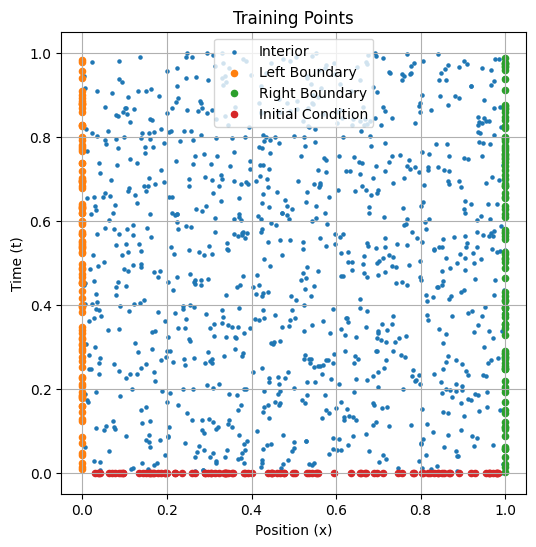

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(x_f,t_f,s=5,label="Interior")
plt.scatter(x_b_left,t_b_left,s=20,label="Left Boundary")
plt.scatter(x_b_right,t_b_right,s=20,label="Right Boundary")
plt.scatter(x_i,t_i,s=20,label="Initial Condition")

plt.xlabel("Position (x)")
plt.ylabel("Time (t)")
plt.title("Training Points")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
x_f = torch.tensor(x_f,dtype=torch.float32,requires_grad=True)
t_f = torch.tensor(t_f,dtype=torch.float32,requires_grad=True)

x_i = torch.tensor(x_i,dtype=torch.float32)
t_i = torch.tensor(t_i,dtype=torch.float32)

x_b_left = torch.tensor(x_b_left,dtype=torch.float32)
t_b_left = torch.tensor(t_b_left,dtype=torch.float32)

x_b_right = torch.tensor(x_b_right,dtype=torch.float32)
t_b_right = torch.tensor(t_b_right,dtype=torch.float32)

In [ ]:
class PINN(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(2,20),

            nn.Tanh(),

            nn.Linear(20,20),

            nn.Tanh(),

            nn.Linear(20,20),

            nn.Tanh(),

            nn.Linear(20,1)

        )

    def forward(self,x):

        return self.network(x)

In [ ]:
model = PINN()

print(model)

PINN(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): Tanh()
    (6): Linear(in_features=20, out_features=1, bias=True)
  )
)


In [ ]:
params = sum(p.numel() for p in model.parameters())

print("Trainable Parameters =",params)

Trainable Parameters = 921


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

mse_loss = nn.MSELoss()

print("Optimizer and Loss Function Initialized")

Optimizer and Loss Function Initialized


In [ ]:
def physics_loss():

    # Interior points
    inputs = torch.cat((x_f, t_f), dim=1)

    u = model(inputs)

    # du/dt
    u_t = torch.autograd.grad(
        u,
        t_f,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # du/dx
    u_x = torch.autograd.grad(
        u,
        x_f,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # d²u/dx²
    u_xx = torch.autograd.grad(
        u_x,
        x_f,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    residual = u_t - alpha * u_xx

    pde_loss = torch.mean(residual**2)

    return pde_loss

In [ ]:
def initial_loss():

    inputs = torch.cat((x_i, t_i), dim=1)

    prediction = model(inputs)

    target = torch.sin(torch.pi*x_i)

    return mse_loss(prediction,target)

In [ ]:
def boundary_loss():

    left_inputs = torch.cat((x_b_left,t_b_left),dim=1)

    right_inputs = torch.cat((x_b_right,t_b_right),dim=1)

    left_prediction = model(left_inputs)

    right_prediction = model(right_inputs)

    left_loss = mse_loss(
        left_prediction,
        torch.zeros_like(left_prediction)
    )

    right_loss = mse_loss(
        right_prediction,
        torch.zeros_like(right_prediction)
    )

    return left_loss + right_loss

In [ ]:
def total_loss():

    return (
        physics_loss()
        + initial_loss()
        + boundary_loss()
    )

In [ ]:
epochs = 2000

loss_history = []

start_time = time.time()

for epoch in range(epochs):

    optimizer.zero_grad()

    loss = total_loss()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 200 == 0:

        print(
            f"Epoch {epoch} | Loss = {loss.item():.6f}"
        )

training_time = time.time() - start_time

print("\nTraining Finished")

print("Training Time:",training_time,"seconds")

Epoch 0 | Loss = 0.775589
Epoch 200 | Loss = 0.168646
Epoch 400 | Loss = 0.098495
Epoch 600 | Loss = 0.032376
Epoch 800 | Loss = 0.011552
Epoch 1000 | Loss = 0.003981
Epoch 1200 | Loss = 0.001677
Epoch 1400 | Loss = 0.001081
Epoch 1600 | Loss = 0.000828
Epoch 1800 | Loss = 0.000705

Training Finished
Training Time: 15.513431310653687 seconds


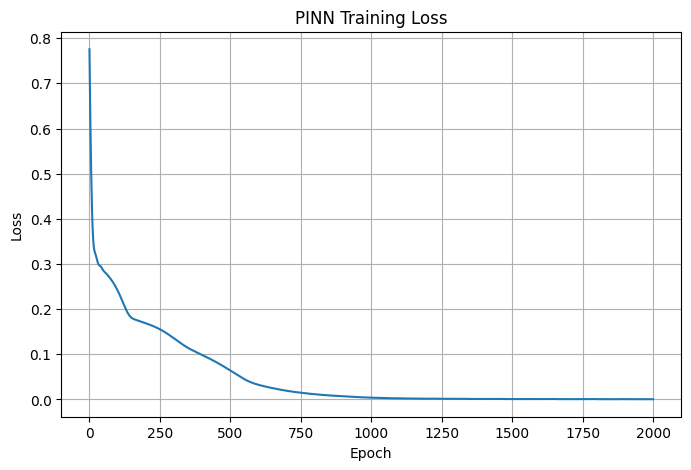

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("PINN Training Loss")

plt.grid(True)

plt.show()

In [ ]:
x_test = np.linspace(0,1,100)

t_test = np.linspace(0,1,100)

X,T = np.meshgrid(x_test,t_test)

X_flat = X.reshape(-1,1)

T_flat = T.reshape(-1,1)

In [ ]:
model.eval()

X_tensor = torch.tensor(X_flat,dtype=torch.float32)

T_tensor = torch.tensor(T_flat,dtype=torch.float32)

test_inputs = torch.cat((X_tensor,T_tensor),dim=1)

with torch.no_grad():

    prediction = model(test_inputs)

prediction = prediction.numpy()

U_pred = prediction.reshape(100,100)

Temperature Map ⭐

This is your first presentation-quality figure.**bold text**

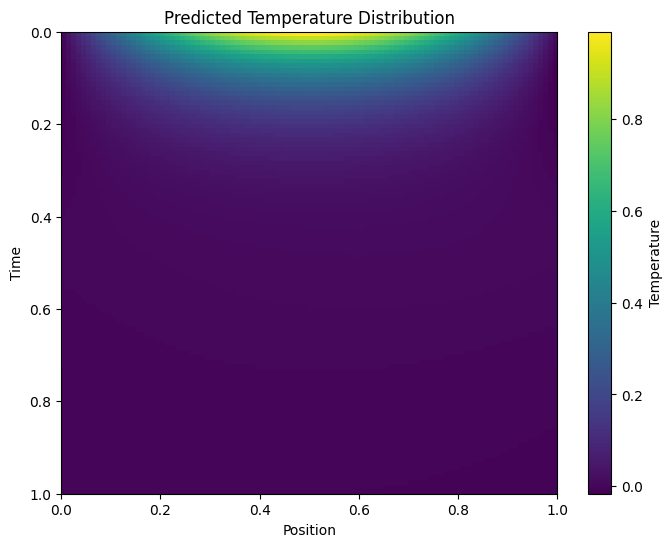

In [ ]:
plt.figure(figsize=(8,6))

plt.imshow(
    U_pred,
    extent=[0,1,1,0],
    aspect="auto"
)

plt.colorbar(label="Temperature")

plt.xlabel("Position")

plt.ylabel("Time")

plt.title("Predicted Temperature Distribution")

plt.show()

PDE Residual Error ⭐

In [ ]:
pde_error = physics_loss().item()

print("PDE Residual Error =",pde_error)

PDE Residual Error = 0.00043778371764346957


Relative L2 Error ⭐

Since we're using the analytical solution:

u(x,t)=e
−π
2
t
sin(πx)

In [ ]:
U_exact = np.exp(-np.pi**2*T)*np.sin(np.pi*X)

relative_l2 = np.linalg.norm(U_exact-U_pred) / np.linalg.norm(U_exact)

print("Relative L2 Error =",relative_l2)

Relative L2 Error = 0.027707321528142894


Memory Usage ⭐

In [ ]:
memory = psutil.Process().memory_info().rss / (1024**2)

print("Memory Usage:",memory,"MB")

Memory Usage: 388.1875 MB


Save **Model**

In [ ]:
torch.save(model.state_dict(),"Heat_PINN_Model.pth")

print("Model Saved")

Model Saved


Final Results Table

In [ ]:
print("="*50)

print("Heat PINN Results")

print("="*50)

print(f"Training Time       : {training_time:.2f} sec")

print(f"PDE Residual Error  : {pde_error:.6e}")

print(f"Relative L2 Error   : {relative_l2:.6e}")

print(f"Trainable Parameters: {params}")

print(f"Memory Usage        : {memory:.2f} MB")

print("="*50)

Heat PINN Results
Training Time       : 15.51 sec
PDE Residual Error  : 4.377837e-04
Relative L2 Error   : 2.770732e-02
Trainable Parameters: 921
Memory Usage        : 388.19 MB
